In [42]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib
import seaborn as sns

current_font_list = matplotlib.rcParams['font.family']

font_path = "C:\Windows\Fonts\HMKMRHD.TTF"
kfont = matplotlib.font_manager.FontProperties(fname=font_path).get_name()

matplotlib.rcParams['font.family'] = [kfont]+current_font_list

pd_data = pd.read_csv('이륜차신고현황_시도별_20230309170628.csv', encoding='cp949',header=1)
pd_data['시점']= pd_data['시점'].astype(np.float64)

pd_data

,시도명(1),시점,시군구(1),경형,소형,중형,대형,경형.1,소형.1,중형.1,대형.1
0,부산,2019.01,금정구,8,17,69,1,319,2348,5080,351
1,부산,2019.01,기장군,7,7,46,0,258,1570,2896,270
2,부산,2019.01,남구,3,12,26,0,463,2845,6735,571
3,부산,2019.01,동구,3,35,38,2,258,994,2783,169
4,부산,2019.01,동래구,5,7,74,0,391,2434,5031,420
...,...,...,...,...,...,...,...,...,...,...,...
715,부산,2022.12,수영구,0,4,80,1,310,1471,4243,681
716,부산,2022.12,연제구,5,4,89,36,273,1587,4338,654
717,부산,2022.12,영도구,5,2,43,0,219,1480,4344,335
718,부산,2022.12,해운대구,7,2,86,1,536,2941,7901,1328


In [39]:
def df_check(df):
    for e in df:
        print('********')
        print(e ,df[e].dtype, df[e].hasnans)
        print(df[e].unique())
# df_check(pd_data)
# pd_data
lista = []
for i in pd_data['시군구(1)']: 
    filter1 = pd_data['시군구(1)']== i
    x = pd_data.loc[filter1,'시점']


AttributeError: 'Series' object has no attribute 'split'

In [89]:
for i,e in enumerate(df_group_f['시군구(1)'].unique()):
    filter1 = df_group_f['시군구(1)'] == e
    print(i,e)

0 금정구
1 기장군
2 남구
3 동구
4 동래구
5 부산기타
6 부산진구
7 북구
8 사상구
9 사하구
10 서구
11 수영구
12 연제구
13 영도구
14 해운대구


C:\Users\ITPS\AppData\Local\Temp\ipykernel_4300\950260689.py:2: FutureWarning: The default value of numeric_only in DataFrameGroupBy.mean is deprecated. In a future version, numeric_only will default to False. Either specify numeric_only or select only columns which should be valid for the function.
  df_group = g1.mean()


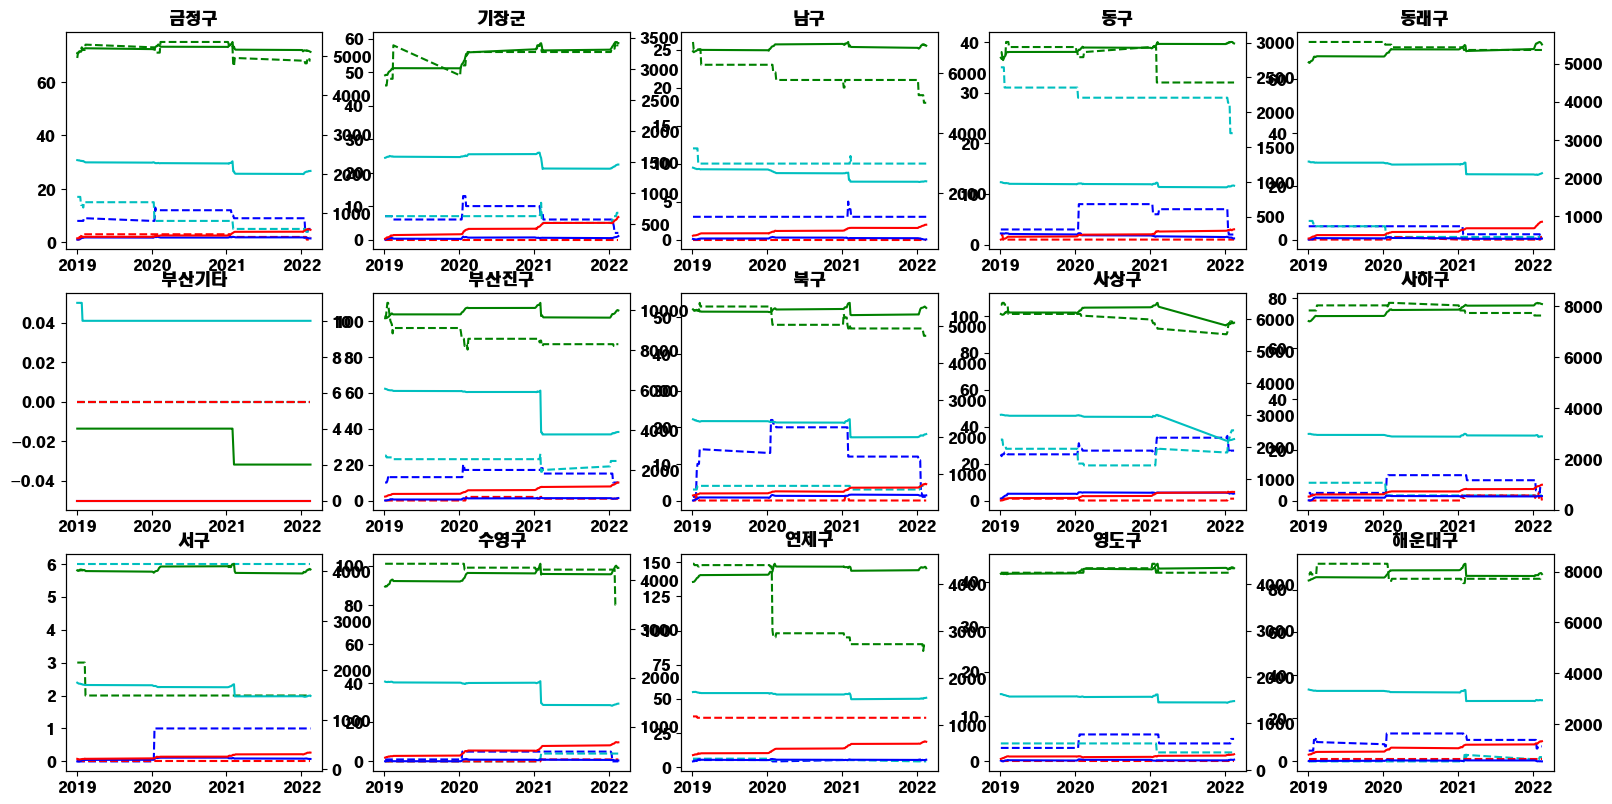

In [105]:
g1 = pd_data.groupby(['시군구(1)','시점'])
df_group = g1.mean()
df_group_f = df_group.reset_index()
fig, axes = plt.subplots(3,5,figsize=(6.4*3, 4.8*2))
col_name = df_group_f.columns
df_group_f
for i,e in enumerate(df_group_f['시군구(1)'].unique()):
    filter1 = df_group_f['시군구(1)'] == e
    ax = axes[i//5,i%5]
    xs = df_group_f.loc[filter1,'시점']
    ys = df_group_f.loc[filter1,col_name]
    ax.set_title(e)
    ax.plot(xs,ys.iloc[:,2], 'b--')
    ax.plot(xs,ys.iloc[:,3], 'c--')
    ax.plot(xs,ys.iloc[:,4], 'g--')    
    ax.plot(xs,ys.iloc[:,5], 'r--')
    ax2 =ax.twinx()
    ax2.plot(xs,ys.iloc[:,6], 'b-')
    ax2.plot(xs,ys.iloc[:,7], 'c-')
    ax2.plot(xs,ys.iloc[:,8], 'g-')    
    ax2.plot(xs,ys.iloc[:,9], 'r-') 
    
# for i, e in enumerate(df2['행정구역별'].unique()):
#     filter1 = df2['행정구역별'] == e
#     ax = axes[i//6, i%6]
#     xs = df2.loc[filter1,'재산피해(계) (천원)']
#     ys = df2.loc[filter1,col_name]
#     ax2.plot(xs.astype('str'),ys.iloc[:,4] , 'bv--')  # 소방공무원수
#     ax2.plot(xs.astype('str'),ys.iloc[:,5] , 'ro-')   # 사건수

In [108]:
g1 = pd_data.groupby(['시군구(1)','시점'])
df_group = g1.mean()
df_group_f = df_group.reset_index()
fig, axes = plt.subplots(3,5,figsize=(6.4*3, 4.8*2))
col_name = df_group_f.columns
df_group_f
for i,e in enumerate(df_group_f['시군구(1)'].unique()):
    filter1 = df_group_f['시군구(1)'] == e
    ax = axes[i//5,i%5]
    xs = df_group_f.loc[filter1,'시점']
    ys = df_group_f.loc[filter1,col_name]
    ax.set_title(e)
    ax.pie(ys.iloc[:,2],radius=1.1)
    

C:\Users\ITPS\AppData\Local\Temp\ipykernel_4300\625402146.py:2: FutureWarning: The default value of numeric_only in DataFrameGroupBy.mean is deprecated. In a future version, numeric_only will default to False. Either specify numeric_only or select only columns which should be valid for the function.
  df_group = g1.mean()
C:\Users\ITPS\AppData\Local\Programs\Python\Python310\lib\site-packages\matplotlib\axes\_axes.py:3168: RuntimeWarning: invalid value encountered in divide
  x = x / sx


ValueError: cannot convert float NaN to integer

ValueError: need at least one array to concatenate

<Figure size 1920x960 with 15 Axes>

C:\Users\ITPS\AppData\Local\Temp\ipykernel_4300\1411965889.py:2: FutureWarning: The default value of numeric_only in DataFrameGroupBy.mean is deprecated. In a future version, numeric_only will default to False. Either specify numeric_only or select only columns which should be valid for the function.
  df_group = g1.mean()
C:\Users\ITPS\AppData\Local\Temp\ipykernel_4300\1411965889.py:8: FutureWarning: In a future version of pandas all arguments of DataFrame.pivot will be keyword-only.
  df_group_pv_s = df_group.reset_index().pivot('시군구(1)','시점', '소형.1')
C:\Users\ITPS\AppData\Local\Temp\ipykernel_4300\1411965889.py:10: FutureWarning: In a future version of pandas all arguments of DataFrame.pivot will be keyword-only.
  df_group_pv_m = df_group.reset_index().pivot('시군구(1)','시점', '중형.1')
C:\Users\ITPS\AppData\Local\Temp\ipykernel_4300\1411965889.py:12: FutureWarning: In a future version of pandas all arguments of DataFrame.pivot will be keyword-only.
  df_group_pv_l = df_group.reset_index

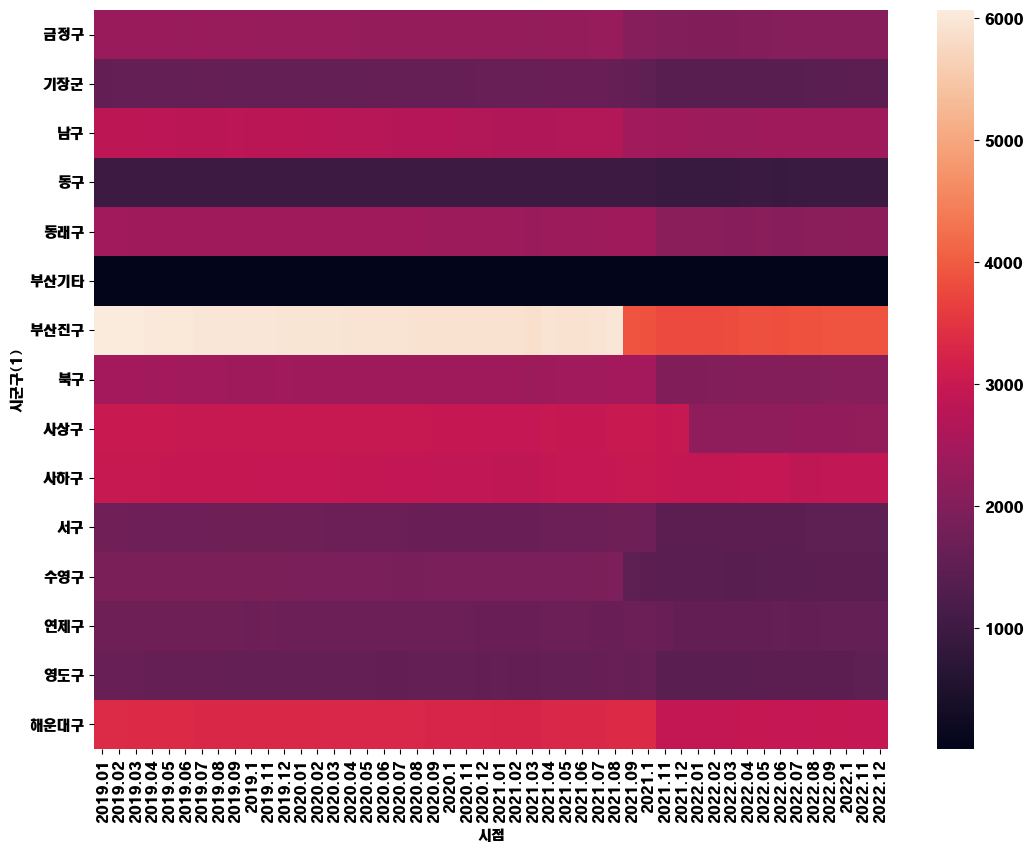

In [77]:
g1 = pd_data.groupby(['시군구(1)','시점'])
df_group = g1.mean()
# df_group

df_group_pv_s = df_group.reset_index().pivot('시군구(1)','시점', '소형.1')
sns.heatmap(df_group_pv_s, ax=ax1)
df_group_pv_m = df_group.reset_index().pivot('시군구(1)','시점', '중형.1')
# b = sns.heatmap(df_group_pv_m)
df_group_pv_l = df_group.reset_index().pivot('시군구(1)','시점', '대형.1')
# c = sns.heatmap(df_group_pv_l)
# print(a)

C:\Users\ITPS\AppData\Local\Temp\ipykernel_4300\3051253620.py:2: FutureWarning: The default value of numeric_only in DataFrameGroupBy.mean is deprecated. In a future version, numeric_only will default to False. Either specify numeric_only or select only columns which should be valid for the function.
  df_group = g1.mean()
C:\Users\ITPS\AppData\Local\Temp\ipykernel_4300\3051253620.py:3: FutureWarning: In a future version of pandas all arguments of DataFrame.pivot will be keyword-only.
  df_group_pv_m = df_group.reset_index().pivot('시군구(1)','시점', '중형.1')


<AxesSubplot: xlabel='시점', ylabel='시군구(1)'>

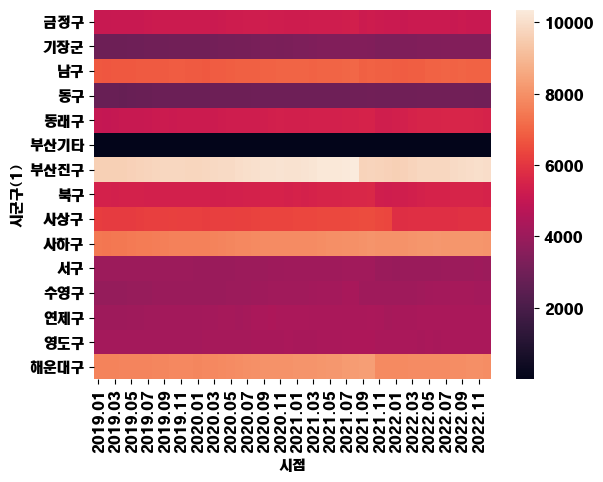

In [64]:
g1 = pd_data.groupby(['시군구(1)','시점'])
df_group = g1.mean()
df_group_pv_m = df_group.reset_index().pivot('시군구(1)','시점', '중형.1')
sns.heatmap(df_group_pv_m)

C:\Users\ITPS\AppData\Local\Temp\ipykernel_4300\3956007359.py:2: FutureWarning: The default value of numeric_only in DataFrameGroupBy.mean is deprecated. In a future version, numeric_only will default to False. Either specify numeric_only or select only columns which should be valid for the function.
  df_group = g1.mean()
C:\Users\ITPS\AppData\Local\Temp\ipykernel_4300\3956007359.py:3: FutureWarning: In a future version of pandas all arguments of DataFrame.pivot will be keyword-only.
  df_group_pv_l = df_group.reset_index().pivot('시군구(1)','시점', '대형.1')


<AxesSubplot: xlabel='시점', ylabel='시군구(1)'>

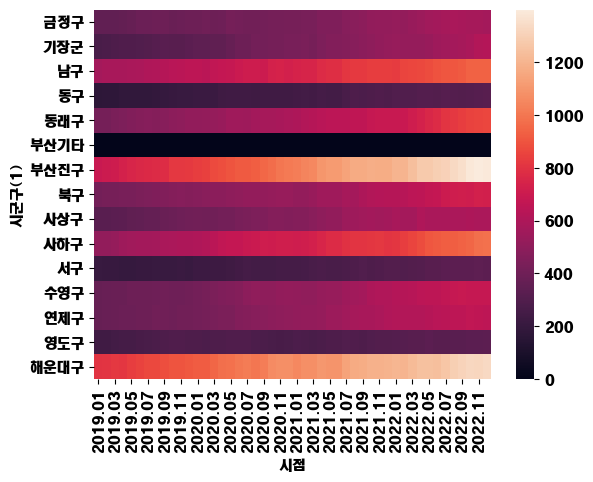

In [63]:
g1 = pd_data.groupby(['시군구(1)','시점'])
df_group = g1.mean()
df_group_pv_l = df_group.reset_index().pivot('시군구(1)','시점', '대형.1')
sns.heatmap(df_group_pv_l)